# RGB e HSV: Rappresentazione e Percezione del Colore
### Laboratorio — Trattamento di Dati Multimediali

---

**Obiettivo:** capire la struttura percettiva di RGB e HSV, quando conviene usare ciascuno spazio e come convertire tra i due in modo consapevole.  
**Strumenti:** Python 3, OpenCV (`cv2`), NumPy, Matplotlib.  

---

## Struttura del notebook

| Sezione | Argomento |
|---|---|
| 0 | Setup e caricamento immagine |
| 1 | RGB — acquisizione, percezione e limiti |
| 2 | HSV — geometria, percezione ed editing |
| 3 | Conversione RGB ↔ HSV: cosa si guadagna e cosa si perde |
| 4 | Applicazione pratica — color picker e segmentazione |
| 5 | Riepilogo — quando usare RGB, quando usare HSV |

> **Nota metodologica:** ogni sezione contiene prima una spiegazione critica del *quando* è utile la trasformazione, poi il codice, poi domande per la discussione. Leggete sempre la spiegazione prima di eseguire le celle.

---
## Sezione 0 — Setup e caricamento immagine

In [6]:
# ── Installazione dipendenze (eseguire solo se necessario) ──────────────────
# !pip install opencv-python matplotlib numpy --quiet

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import urllib.request
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': '#F8F9FA',
    'axes.facecolor':   '#F8F9FA',
    'axes.titlesize':   11,
    'axes.titleweight': 'bold',
    'font.family':      'DejaVu Sans',
})

print(f'✓ OpenCV {cv2.__version__}  |  NumPy {np.__version__}')

✓ OpenCV 4.13.0  |  NumPy 2.4.4


✓ Immagine scaricata


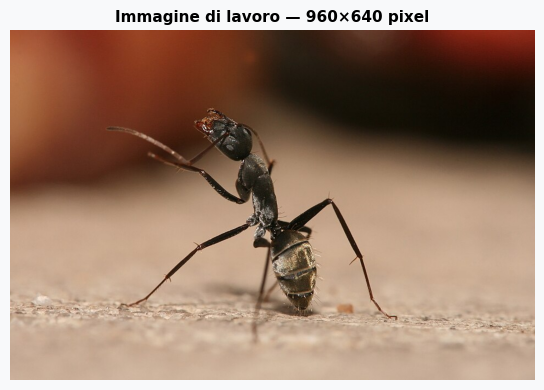

In [ ]:
# ── Caricamento immagine ────────────────────────────────────────────────────
# OPZIONE A — immagine locale
# img_bgr = cv2.imread('test_image.jpg')
#
# OPZIONE B — download automatico
URL = 'https://raw.githubusercontent.com/luigi-asprino/LAB-TDM/refs/heads/main/003/Camponotus_flavomarginatus_ant.jpg'
def load_image_bgr(URL):
    try:
        with urllib.request.urlopen(URL) as resp:
            arr = np.frombuffer(resp.read(), np.uint8)
            img_bgr = cv2.imdecode(arr, cv2.IMREAD_COLOR)
        print('✓ Immagine scaricata')
        return img_bgr
    except Exception:
        print('⚠  Download fallito — uso immagine sintetica')
        img_bgr = np.zeros((300, 400, 3), dtype=np.uint8)
        img_bgr[:, :100]    = [0,   0,   220]   # rosso (BGR)
        img_bgr[:, 100:200] = [0,   180, 100]   # arancione
        img_bgr[:, 200:300] = [0,   200, 0]     # verde
        img_bgr[:, 300:]    = [200, 0,   0]     # blu
        img_bgr[120:180, :] = [200, 200, 200]   # grigio

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    IMG_H, IMG_W = img_rgb.shape[:2]

    plt.figure(figsize=(6, 4))
    plt.imshow(img_rgb)
    plt.title(f'Immagine di lavoro — {IMG_W}×{IMG_H} pixel')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

img_bgr = load_image_bgr(URL)

---
## Sezione 1 — RGB: acquisizione, percezione e limiti

### Cos'è RGB e perché esiste?

RGB è lo spazio colore *nativo* di fotocamere, display e GPU. Ogni pixel è un vettore `(R, G, B)` con valori in `[0, 255]`, dove ciascuna componente rappresenta l'intensità luminosa di una delle tre primarie additive — rosso, verde, blu.

La scelta di tre primarie non è arbitraria: rispecchia la struttura biologica dell'occhio umano, che contiene tre tipi di coni con picchi di sensibilità spettrale nel rosso-arancione (coni L), nel verde-giallo (coni M) e nel blu-violetto (coni S). Qualsiasi colore percepibile dall'uomo può essere descritto come una combinazione di questi tre stimoli — è il principio della **tricromia**.

---

### 📷 Come nasce un'immagine RGB: il demosaicing

I sensori delle fotocamere digitali **non acquisiscono direttamente** un'immagine RGB completa. Ogni fotosito registra un solo colore alla volta grazie al **filtro di Bayer**, che dispone i filtri cromatici in questo schema ripetuto:

```
R  G  R  G  R  G
G  B  G  B  G  B
R  G  R  G  R  G
G  B  G  B  G  B
```

I pixel **verdi sono il doppio** degli altri: scelta non casuale, ma motivata dalla maggiore sensibilità dell'occhio al verde (i coni M dominano nella fovea). Il **demosaicing** è il processo che *ricostruisce* i tre canali per ogni pixel interpolando i valori dei vicini. Gli algoritmi semplici usano l'interpolazione bilineare; quelli avanzati (AHD, LMMSE) tengono conto dei bordi per evitare il *color fringing* (aloni colorati ai contorni).

> **Implicazione:** l'immagine RGB che usate è già il risultato di un'elaborazione. I file **RAW** contengono i dati grezzi prima del demosaicing — per questo offrono più flessibilità in post-produzione.

---

### 👁️ Percezione in RGB: i canali non sono equivalenti

I tre canali RGB **non contribuiscono ugualmente** alla luminosità percepita. L'occhio umano è molto più sensibile al verde che al rosso e al blu. Quando si converte in scala di grigi non si fa la media aritmetica, ma una **media ponderata** che rispetta la sensibilità spettrale:

```
Y = 0.299·R + 0.587·G + 0.114·B    (BT.601 — video SD)
Y = 0.213·R + 0.715·G + 0.072·B    (BT.709 — video HD)
```

Il verde contribuisce circa il **60%** della luminosità percepita, il rosso il **30%**, il blu solo il **10%**. Questo significa:
- Il **canale G** è il più simile a una versione in scala di grigi dell'immagine.
- Il **canale B** appare spesso scuro anche in zone che percepiamo come luminose.
- Per aumentare la luminosità di un'immagine in RGB bisogna modificare **tutti e tre** i canali — non è un'operazione intuitiva.

### 🎨 Operazioni native di RGB

RGB è ideale per operazioni che sfruttano la sua natura **additiva e lineare**:

- **Miscelazione di colori:** la miscela di due colori A e B si calcola come `t·A + (1-t)·B` con `t ∈ [0,1]`. Funziona componente per componente perché RGB è additivo.
- **Blending (alpha compositing):** sovrapporre un foreground su uno sfondo con trasparenza — `C_out = α·C_fg + (1−α)·C_bg`. È la base di ogni sistema di layer (Photoshop, UI, rendering 3D). Funziona in RGB perché ogni canale si combina indipendentemente.
- **Sintesi procedurale:** gradienti, texture noise (Perlin, Simplex), materiali 3D — tutti calcolati componente per componente in RGB nei motori di rendering e negli shader.

> **Nota importante:** il blending fisicamente corretto richiede RGB *lineare* (senza gamma correction). L'sRGB standard ha una curva gamma ≈ 2.2 che distorce l'aritmetica lineare. Se lavorate con blending di precisione, linearizzate prima.

### ⚠️ Il problema fondamentale di RGB: accoppiamento luminanza-colore

In RGB, la **luminosità** e il **tipo di colore** sono mescolati nelle stesse tre componenti. Questo causa problemi concreti:

1. **Editing selettivo impossibile senza maschera:** modificare solo la luminosità richiede di toccare tutti e tre i canali contemporaneamente, con rischio di alterare il colore.
2. **Segmentazione per colore instabile:** un rosso in luce piena (`R=220, G=30, B=30`) e lo stesso rosso in ombra (`R=80, G=10, B=10`) hanno valori RGB completamente diversi, pur essendo percepiti come «lo stesso colore».
3. **Distanza euclidea ≠ differenza percepita:** due colori con uguale distanza euclidea in RGB possono sembrare molto diversi o quasi identici all'occhio.

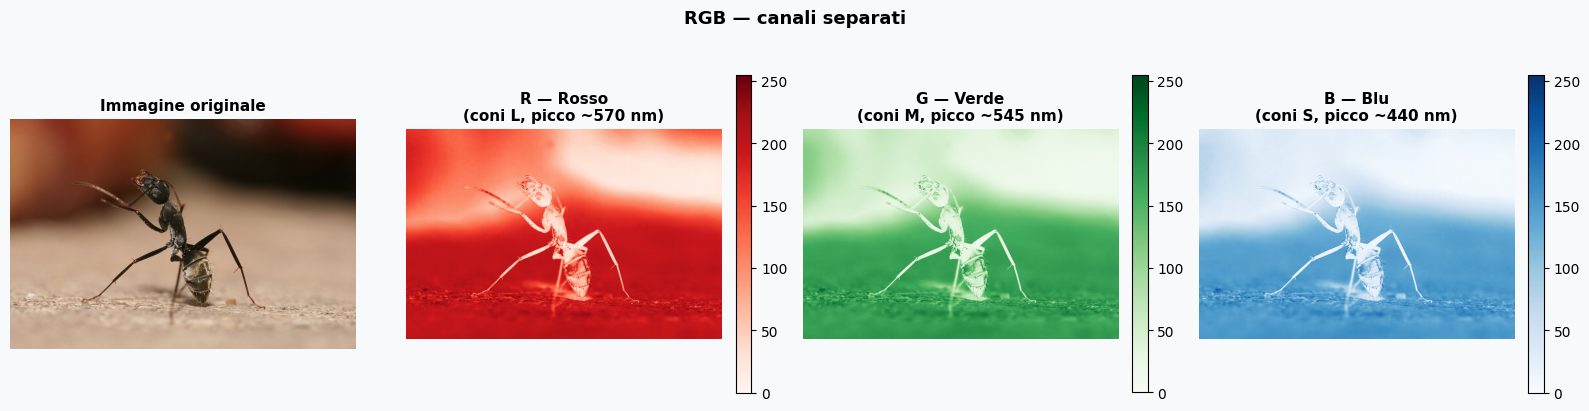

Statistiche per canale (media ± dev.std.):
  R: 145.6 ± 63.7
  G: 112.7 ± 62.9
  B: 91.2 ± 59.1


In [9]:
# ── 1a. Separazione canali RGB ──────────────────────────────────────────────
R, G, B = img_rgb[:, :, 0], img_rgb[:, :, 1], img_rgb[:, :, 2]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle('RGB — canali separati', fontsize=13, fontweight='bold', y=1.02)

axes[0].imshow(img_rgb)
axes[0].set_title('Immagine originale')

for ax, ch, cmap, label in zip(
        axes[1:],
        [R, G, B],
        ['Reds', 'Greens', 'Blues'],
        ['R — Rosso\n(coni L, picco ~570 nm)',
         'G — Verde\n(coni M, picco ~545 nm)',
         'B — Blu\n(coni S, picco ~440 nm)']):
    im = ax.imshow(ch, cmap=cmap, vmin=0, vmax=255)
    ax.set_title(label)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

for ax in axes:
    ax.axis('off')

plt.tight_layout()
plt.savefig('out_1a_rgb_channels.png', dpi=150, bbox_inches='tight')
plt.show()

print('Statistiche per canale (media ± dev.std.):')
for name, ch in zip(['R', 'G', 'B'], [R, G, B]):
    print(f'  {name}: {ch.mean():.1f} ± {ch.std():.1f}')

## I pesi percettivi: media aritmetica vs. ponderata 

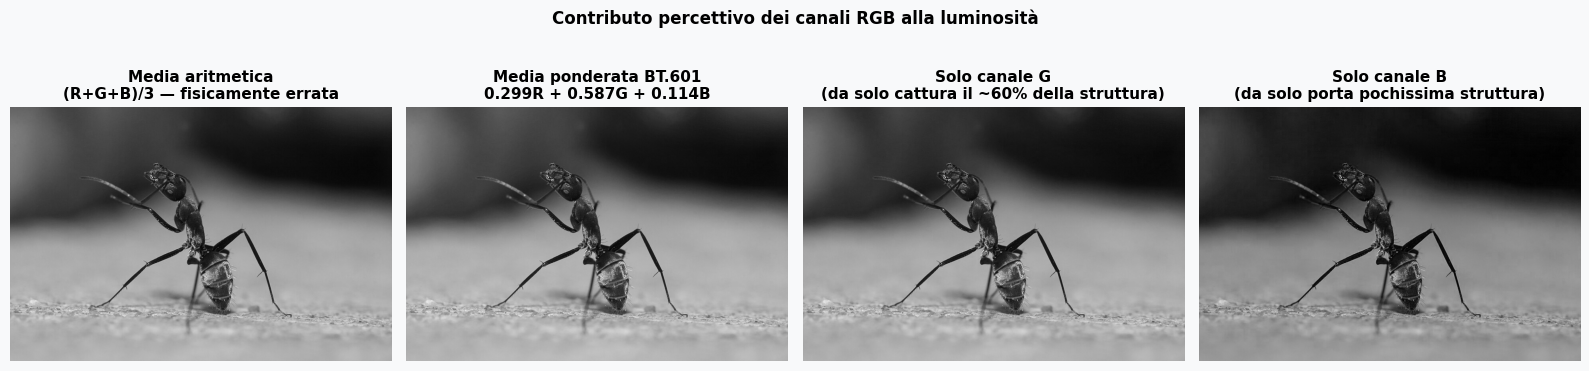

Correlazione di ciascun canale con la luminanza BT.601 (proxy percettivo):
  R: r = 0.978
  G: r = 0.997
  B: r = 0.989


In [14]:
def correlazione_precettiva(R, G, B, image_name):
    gray_equal = (R.astype(float) + G.astype(float) + B.astype(float)) / 3
    gray_bt601  = 0.299 * R + 0.587 * G + 0.114 * B
    gray_only_G = G.astype(float)
    gray_only_B = B.astype(float)

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    fig.suptitle('Contributo percettivo dei canali RGB alla luminosità', fontsize=12, fontweight='bold', y=1.02)

    panels = [
    (gray_equal,  'Media aritmetica\n(R+G+B)/3 — fisicamente errata'),
    (gray_bt601,  'Media ponderata BT.601\n0.299R + 0.587G + 0.114B'),
    (gray_only_G, 'Solo canale G\n(da solo cattura il ~60% della struttura)'),
    (gray_only_B, 'Solo canale B\n(da solo porta pochissima struttura)'),
]
    for ax, (ch, title) in zip(axes, panels):
        ax.imshow(ch.astype(np.uint8), cmap='gray', vmin=0, vmax=255)
        ax.set_title(title)
        ax.axis('off')

    plt.tight_layout()
    plt.savefig(f"out_1b_luminance_weights_{image_name}.png", dpi=150, bbox_inches='tight')
    plt.show()

# Correlazione di ciascun canale con la luminanza ponderata (ground truth percettiva)
    print('Correlazione di ciascun canale con la luminanza BT.601 (proxy percettivo):')
    for name, ch in zip(['R', 'G', 'B'], [R, G, B]):
        corr = np.corrcoef(ch.flatten(), gray_bt601.flatten())[0, 1]
        print(f'  {name}: r = {corr:.3f}')

correlazione_precettiva(R, G, B, "test_image1")

In [ ]:
# ── 1c. Il problema dell'accoppiamento: stesso colore, valori diversi ───────
#
# Dimostriamo che in RGB lo stesso tipo di colore ha valori completamente
# diversi al variare della luminosità — rendendo la segmentazione difficile.

# Creiamo una striscia dello stesso colore (rosso) a diverse luminosità
hue_angle = 0   # rosso puro
samples = []
brightness_levels = [0.15, 0.30, 0.50, 0.70, 0.85, 1.0]

for v in brightness_levels:
    # Pixel HSV: H=0° (rosso), S=1 (saturo), V variabile
    hsv_pixel = np.array([[[0, 255, int(v * 255)]]], dtype=np.uint8)
    bgr_pixel = cv2.cvtColor(hsv_pixel, cv2.COLOR_HSV2BGR)
    rgb_pixel = cv2.cvtColor(bgr_pixel, cv2.COLOR_BGR2RGB)
    r, g, b = rgb_pixel[0, 0]
    samples.append((v, int(r), int(g), int(b)))

# Visualizzazione
swatch_w = 80
swatches = np.zeros((80, swatch_w * len(samples), 3), dtype=np.uint8)
for i, (v, r, g, b) in enumerate(samples):
    swatches[:, i*swatch_w:(i+1)*swatch_w] = [r, g, b]

fig, axes = plt.subplots(1, 2, figsize=(14, 4),
                          gridspec_kw={'width_ratios': [3, 2]})
fig.suptitle('Stesso colore (rosso saturo), luminosità crescente — valori RGB molto diversi',
             fontsize=11, fontweight='bold')

axes[0].imshow(swatches)
axes[0].set_xticks([swatch_w * i + swatch_w // 2 for i in range(len(samples))])
axes[0].set_xticklabels([f'V={v:.0%}' for v, *_ in samples])
axes[0].set_yticks([])
axes[0].set_title('← stesso colore percettivo → valori RGB molto diversi')

labels = [f'V={v:.0%}' for v, *_ in samples]
r_vals = [r for _, r, g, b in samples]
g_vals = [g for _, r, g, b in samples]
b_vals = [b for _, r, g, b in samples]
x = range(len(samples))

axes[1].plot(x, r_vals, 'o-', color='crimson',  label='R')
axes[1].plot(x, g_vals, 's-', color='seagreen',  label='G')
axes[1].plot(x, b_vals, '^-', color='steelblue', label='B')
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(labels)
axes[1].set_ylabel('Valore canale (0–255)')
axes[1].set_title('Variazione dei valori RGB\nal variare solo della luminosità')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('out_1c_coupling_problem.png', dpi=150, bbox_inches='tight')
plt.show()

print('Valori RGB per rosso saturo a diverse luminosità:')
print(f'{"Luminosità":>12} | {"R":>5} {"G":>5} {"B":>5}')
print('-' * 35)
for v, r, g, b in samples:
    print(f'{v:>12.0%} | {r:>5} {g:>5} {b:>5}')
print()
print('→ In RGB non esiste una soglia semplice su R, G, B che identifichi')
print('  "tutti i rossi" indipendentemente dalla luminosità.')
print('  In HSV, invece, H = 0° per tutti questi pixel.')

### 💬 Domande per la discussione — RGB

1. Osservate il grafico dei valori RGB al variare della luminosità. Il canale G cresce, ma rimane sempre molto piccolo rispetto a R. Perché un rosso «puro» ha G ≈ 0 anche ad alta luminosità?
2. Perché la media ponderata BT.601 produce una scala di grigi «più naturale» della media aritmetica? Su quali zone dell'immagine la differenza è più evidente?
3. Se volete scrivere una funzione che rileva i pixel «rossi» in un'immagine RGB, quali problemi incontrate? Come li risolvereste?
4. Il demosaicing introduce una stima dei valori mancanti. Cosa succederebbe se invece di interpolare usaste semplicemente il valore del pixel più vicino (nearest-neighbor)?

---

## Sezione 2 — HSV: geometria, percezione ed editing

### Cos'è HSV e perché è stato introdotto?

HSV (Hue, Saturation, Value) è uno spazio colore progettato per **separare le tre dimensioni con cui gli esseri umani descrivono i colori nel linguaggio naturale**: «è un rosso brillante» (H≈0°, S alto), «è un colore spento» (S basso), «è scuro» (V basso). Nasce nel 1978 da Alvy Ray Smith (poi cofondatore di Pixar) come risposta alla difficoltà di lavorare con RGB in applicazioni grafiche.

---

### 👁️ Significato percettivo dei tre canali

#### H — Hue (Tonalità): *«di che tipo di colore si tratta?»*

H risponde alla domanda fondamentale del colore: distingue il rosso dal verde, il blu dal giallo, *indipendentemente da quanto è chiaro o brillante*. Corrisponde approssimativamente alla **lunghezza d'onda dominante** della luce percepita.

**Perché H è un angolo?** Perché lo spazio HSV è geometricamente un **cono** (o cilindro). I colori dell'arcobaleno si dispongono lungo la circonferenza della base:

```
   0° / 360°  →  Rosso
        60°   →  Giallo
       120°   →  Verde
       180°   →  Ciano
       240°   →  Blu
       300°   →  Magenta
```

La struttura circolare rispecchia la **continuità percettiva** dei colori: non c'è un inizio o una fine, ma una successione ciclica. La distanza angolare tra due tonalità corrisponde approssimativamente alla distanza percepita sul cerchio cromatico. Il rosso a 0° e a 360° è lo stesso colore — lo spazio si «chiude» sul rosso, e questa è la principale complessità implementativa di HSV.

In OpenCV, H è compresso nel range `[0, 180]` (metà angolo) per stare in un byte `uint8`. Quando leggete `H=90` in OpenCV, il vero angolo è 180° (ciano).

**Stabilità percettiva di H:** la tonalità rimane stabile quando cambia l'illuminazione (che modifica V) o la purezza cromatica (che modifica S). Questa proprietà è fondamentale per la **costanza del colore** — il meccanismo con cui riconoscete un oggetto come «rosso» sia alla luce del sole che in ombra.

**Instabilità di H per S bassa:** quando S → 0 (zona grigia), H è *matematicamente indefinito*. Un pixel grigio non ha una tonalità. Questo è la singolarità più importante da gestire nelle applicazioni.

#### S — Saturation (Saturazione): *«quanto è vivace o puro?»*

S è la distanza dal centro (grigio neutro) verso il bordo (colore puro) della sezione orizzontale del cono. Percettivamente distingue:

- **S = 0** → grigio neutro: il colore è completamente «spento», privo di cromaticità. Non importa quale sia H.
- **S = 0.5** → colore pastello o tenue: come se fosse mescolato con il grigio.
- **S = 1** → colore pieno, vibrante, puro: come un inchiostro saturo o un LED al massimo.

S è legata al concetto psicofisico di **croma**: due colori con stessa tonalità ma diversa saturazione si differenziano per quanto «colorato» appare il pixel rispetto al grigio di uguale luminosità. Un tramonto arancione saturo ha S alto; una nebbia grigio-arancione ha S basso.

#### V — Value (Valore): *«quanto è chiaro o scuro?»*

V è la posizione lungo l'asse verticale del cono: dall'apice (nero assoluto, V=0) alla base (colore massimamente brillante, V=1).

Percettivamente, V corrisponde alla luminosità nel senso intuitivo. Ma **V ≠ luminanza percettiva**: V è `max(R, G, B)`, mentre la luminanza percettiva è `0.299R + 0.587G + 0.114B`. La differenza è rilevante:

- Un giallo puro `(R=255, G=255, B=0)` ha V = 1 e luminanza BT.601 = 0.886 → sembra molto luminoso ✓
- Un blu puro `(R=0, G=0, B=255)` ha V = 1 ma luminanza BT.601 = 0.114 → sembra molto scuro ✗

Entrambi hanno V = 1, ma il giallo sembra molto più luminoso del blu! Questo è il limite percettivo di HSV: V non è un indicatore affidabile della luminosità *percepita*. Se servono misure accurate di luminanza, si usa YCbCr o CIELAB.

---

### 🍊 Perché HSV è comodo per l'editing selettivo per colore

Uno degli use-case più potenti di HSV è la **correzione selettiva per tonalità**: modificare solo i pixel di un certo colore (es. solo i toni arancioni della pelle, solo il cielo, solo la vegetazione) senza toccare il resto.

In **RGB** questo è difficile: un pixel arancione chiaro ha valori `R=240, G=130, B=40`; uno scuro ha `R=120, G=65, B=20`. Stesso tipo di colore, valori completamente diversi. Non esiste una soglia semplice su R, G, B.

In **HSV** invece: entrambi hanno H ≈ 28° (arancione), indipendentemente da V (luminosità) e S (saturazione). Si filtra con `H ∈ [20°, 40°]` e si ottengono *tutti* i pixel arancioni, chiari o scuri che siano. Poi si può:
- alzare S per toni della pelle più caldi;
- abbassare V per scurire selettivamente;
- spostare H di qualche grado per correggere una cast cromatica.

Questa logica è alla base dei pannelli **HSL/Hue vs. Saturation** di Lightroom, Photoshop e DaVinci Resolve.

---

### 🚦 HSV per il rilevamento dei segnali stradali

Il rilevamento di segnali stradali colorati è uno dei casi d'uso classici nella visione artificiale e nella guida autonoma. La pipeline tipica:

1. Convertire il frame video in HSV;
2. Applicare `cv2.inRange` su un intervallo di H + soglia su S (esclude grigi) + soglia su V (esclude il nero);
3. Trovare blob connessi nella maschera binaria;
4. Validare geometricamente (forma, dimensione, proporzioni) e temporalmente (consistenza su più frame).

**Perché HSV funziona:** V assorbe le variazioni di intensità luminosa (giorno/notte, sole/ombra), lasciando H relativamente stabile. Un segnale rosso di stop ha H ≈ 0° sia in pieno sole (`R=200, G=30, B=30`) che in ombra (`R=80, G=10, B=10`).

**Limite importante:** HSV non è invariante all'illuminazione *colorata* (es. tunnel con lampade al sodio arancione: tutta la scena acquisisce una cast arancione e H di molti pixel si sposta). I sistemi robusti aggiungono white balancing adattivo o usano spazi più sofisticati.

---

### ⚠️ Quando HSV è un'idea sbagliata

- **Compressione video/JPEG**: HSV non separa luminanza da crominanza in modo compatibile con gli standard video (quello si fa con YCbCr).
- **Confronto quantitativo tra colori**: le distanze euclidee in HSV non corrispondono a differenze percepite (usare CIELAB per ΔE).
- **Deep learning**: i modelli pre-addestrati (ImageNet, COCO) usano RGB. Convertire in HSV senza motivazione specifica riduce le performance.
- **Segmentazione del rosso**: richiede due intervalli separati per via della discontinuità a 0°/360°.

In [ ]:
# ── 2a. Separazione canali HSV ──────────────────────────────────────────────
# OpenCV: input BGR, H ∈ [0,180], S e V ∈ [0,255]
img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
H_ch, S_ch, V_ch = img_hsv[:, :, 0], img_hsv[:, :, 1], img_hsv[:, :, 2]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle('HSV — canali separati', fontsize=13, fontweight='bold', y=1.02)

axes[0].imshow(img_rgb)
axes[0].set_title('RGB originale')

configs = [
    (H_ch, 'hsv',  'H — Tonalità\n«Che tipo di colore?»\nValori OpenCV [0,180] = angoli [0°,360°]'),
    (S_ch, 'gray', 'S — Saturazione\n«Quanto è vivace/puro?»\n(0=grigio, 255=colore puro)'),
    (V_ch, 'gray', 'V — Valore\n«Quanto è luminoso?»\n(0=nero, 255=massima luce)'),
]
for ax, (ch, cmap, label) in zip(axes[1:], configs):
    im = ax.imshow(ch, cmap=cmap, vmin=0, vmax=255)
    ax.set_title(label)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

for ax in axes: ax.axis('off')
plt.tight_layout()
plt.savefig('out_2a_hsv_channels.png', dpi=150, bbox_inches='tight')
plt.show()

# Statistiche
print('Zone a bassa saturazione (S < 30) — H è instabile/indefinito:')
low_s_mask = S_ch < 30
print(f'  {low_s_mask.mean()*100:.1f}% dei pixel ha S < 30')
print(f'  In queste zone, H varia da {H_ch[low_s_mask].min()} a {H_ch[low_s_mask].max()} — puro rumore!')

In [ ]:
# ── 2b. Cerchio cromatico: geometria angolare di H ─────────────────────────
#
# Visualizzare il cerchio HSV per capire perché H è un angolo
# e perché il rosso è discontinuo agli estremi.

# Striscia spettrale
rainbow = np.zeros((70, 360, 3), dtype=np.uint8)
for h in range(360):
    rainbow[:, h] = [h // 2, 230, 220]
rainbow_rgb = cv2.cvtColor(cv2.cvtColor(rainbow, cv2.COLOR_HSV2BGR), cv2.COLOR_BGR2RGB)

# Cerchio cromatico vero
size = 300
cx, cy = size // 2, size // 2
circle_img = np.zeros((size, size, 3), dtype=np.uint8)
for y in range(size):
    for x in range(size):
        dx, dy = x - cx, y - cy
        dist = np.sqrt(dx**2 + dy**2)
        if dist <= cx - 5:
            angle = (np.degrees(np.arctan2(-dy, dx)) % 360)
            sat   = min(255, int(dist / (cx - 5) * 255))
            circle_img[y, x] = [int(angle / 2), sat, 220]
circle_rgb = cv2.cvtColor(cv2.cvtColor(circle_img, cv2.COLOR_HSV2BGR), cv2.COLOR_BGR2RGB)

fig = plt.figure(figsize=(14, 5))
gs  = fig.add_gridspec(1, 2, width_ratios=[2, 1])

ax1 = fig.add_subplot(gs[0])
ax1.imshow(rainbow_rgb, aspect='auto')
ax1.set_title('Cerchio cromatico "aperto" — H da 0° a 360°\nIl ROSSO appare agli estremi: lo spazio è ciclico!',
              fontsize=10)
ax1.set_xticks(range(0, 361, 60))
ax1.set_xticklabels(['0°\nRosso','60°\nGiallo','120°\nVerde','180°\nCiano','240°\nBlu','300°\nMagenta','360°\nRosso'])
ax1.set_yticks([])
ax1.annotate('Stesso colore!', xy=(0, 35), xytext=(30, 62),
             arrowprops=dict(arrowstyle='->', color='white'), color='white', fontsize=9)
ax1.annotate('', xy=(358, 35), xytext=(318, 62),
             arrowprops=dict(arrowstyle='->', color='white'))

ax2 = fig.add_subplot(gs[1])
ax2.imshow(circle_rgb)
ax2.set_title('Cerchio cromatico HSV\n(V=costante, S=distanza dal centro)', fontsize=10)
# Annotazioni angoli
for angle_deg, label in [(0,'0°\nR'),(60,'60°\nY'),(120,'120°\nG'),(180,'180°\nC'),(240,'240°\nB'),(300,'300°\nM')]:
    rad = np.radians(angle_deg)
    px  = int(cx + (cx-20) * np.cos(rad))
    py  = int(cy - (cy-20) * np.sin(rad))
    ax2.text(px, py, label, ha='center', va='center', fontsize=7,
             color='white', fontweight='bold')
ax2.axis('off')

plt.tight_layout()
plt.savefig('out_2b_hue_circle.png', dpi=150, bbox_inches='tight')
plt.show()

print('NOTA TECNICA (OpenCV):')
print('  OpenCV usa H ∈ [0, 180] — metà angolo per stare in uint8.')
print('  H=0 (OpenCV) → 0°   (rosso)')
print('  H=30 (OpenCV) → 60°  (giallo)')
print('  H=60 (OpenCV) → 120° (verde)')
print('  H=90 (OpenCV) → 180° (ciano)')
print('  Per convertire: angolo_reale = H_opencv × 2')

In [ ]:
# ── 2c. Editing percettivo indipendente: H, S, V ────────────────────────────
#
# Dimostriamo che in HSV le tre dimensioni percettive sono davvero indipendenti.
# Ogni modifica tocca una sola «leva».

def hsv_edit(img_bgr, h_shift=0, s_scale=1.0, v_scale=1.0):
    """Modifica H, S, V indipendentemente e restituisce un'immagine RGB."""
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV).astype(np.float32)
    hsv[:, :, 0] = (hsv[:, :, 0] + h_shift) % 180         # rotazione tonalità
    hsv[:, :, 1] = np.clip(hsv[:, :, 1] * s_scale, 0, 255) # scala saturazione
    hsv[:, :, 2] = np.clip(hsv[:, :, 2] * v_scale, 0, 255) # scala luminosità
    return cv2.cvtColor(cv2.cvtColor(hsv.astype(np.uint8),
                        cv2.COLOR_HSV2BGR), cv2.COLOR_BGR2RGB)

edits = [
    (img_rgb,                          'Originale',
     'Nessuna modifica'),
    (hsv_edit(img_bgr, h_shift=22),    'H +45°  (tonalità ruotata)',
     'Solo il «tipo di colore» cambia.\nLuminosità e vivacità restano identiche.'),
    (hsv_edit(img_bgr, h_shift=45),    'H +90°  (tonalità ruotata +90°)',
     'Rotazione maggiore: colori complementari.\nStessa struttura luminosa.'),
    (hsv_edit(img_bgr, s_scale=0.25),  'S ×0.25  (quasi desaturato)',
     'Solo la vivacità diminuisce.\nTonalità e luminosità restano identiche.'),
    (hsv_edit(img_bgr, s_scale=1.8),   'S ×1.8  (iper-saturato)',
     'Solo la vivacità aumenta.\nTonalità e luminosità restano identiche.'),
    (hsv_edit(img_bgr, v_scale=0.4),   'V ×0.4  (molto più scuro)',
     'Solo la luminosità cala.\nIl colore (H, S) resta identico.'),
    (hsv_edit(img_bgr, v_scale=1.5),   'V ×1.5  (più chiaro)',
     'Solo la luminosità aumenta.\nIl colore (H, S) resta identico.'),
    (hsv_edit(img_bgr, h_shift=22, s_scale=1.4, v_scale=0.85),
     'H+45° + S×1.4 + V×0.85',
     'Combinazione: shift colore +\npiù saturo + leggermente più scuro.'),
]

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle('Editing indipendente sulle tre dimensioni percettive di HSV', fontsize=13, fontweight='bold')

for ax, (img, title, note) in zip(axes.flatten(), edits):
    ax.imshow(img)
    ax.set_title(f'{title}\n{note}', fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.savefig('out_2c_hsv_independent_edits.png', dpi=150, bbox_inches='tight')
plt.show()

### 💬 Domande per la discussione — HSV

1. Confrontate l'immagine originale con quella desaturata (S×0.25). Come cambia la percezione delle forme e dei dettagli? Perché la struttura è quasi identica?
2. Le due immagini con H ruotato (+45° e +90°) hanno la stessa luminosità e saturazione dell'originale. Verificatelo: come calcolereste la luminanza media di ciascuna?
3. Perché l'editing V×1.5 produce zone sovra-esposte (bianco) ma non l'editing S×1.8? Cosa distingue V da S a livello geometrico nel cono HSV?
4. L'editor di tonalità in Lightroom opera su H selettivamente per range di tonalità. Come implementereste questa funzione con `cv2.inRange`?

---

## Sezione 3 — Conversione RGB ↔ HSV: cosa si guadagna e cosa si perde

### La conversione matematica

La conversione RGB → HSV è una trasformazione **non lineare e non invertibile in modo perfetto a 8 bit**. A partire da RGB normalizzato in `[0,1]`:

```
M = max(R, G, B)        m = min(R, G, B)        Δ = M − m

V = M

S = 0           se M = 0
S = Δ / M       altrimenti

H = indefinito          se Δ = 0  (grigio)
H = 60° × (G−B)/Δ      se M = R
H = 60° × (B−R)/Δ + 120°  se M = G
H = 60° × (R−G)/Δ + 240°  se M = B
H = H + 360°            se H < 0
```

### Cosa si guadagna con la conversione

- **Separazione delle dimensioni percettive:** H, S, V sono ortogonali nel senso percettivo — modificare uno non obbliga a modificare gli altri.
- **Robustezza alla variazione di illuminazione:** H è stabile quando V varia (stesso colore, luce diversa).
- **Segmentazione più semplice:** un threshold su H+S è più robusto di un threshold su R,G,B.

### Cosa si perde o introduce la conversione

- **Errori di quantizzazione a 8 bit:** la conversione usa operazioni in virgola mobile; la quantizzazione a 8 bit introduce un errore che varia per zona dell'immagine.
- **Instabilità di H per S bassa:** nelle zone quasi-grigie, piccole variazioni di R,G,B producono grandi variazioni di H — amplificazione del rumore.
- **Discontinuità del rosso:** H è discontinuo a 0°/360°, complicando operazioni che coinvolgono i rossi.

In [ ]:
# ── 3a. Errore di round-trip RGB → HSV → RGB ────────────────────────────────

img_hsv_conv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
img_back_bgr = cv2.cvtColor(img_hsv_conv, cv2.COLOR_HSV2BGR)
img_back_rgb = cv2.cvtColor(img_back_bgr, cv2.COLOR_BGR2RGB)

err = np.abs(img_rgb.astype(int) - img_back_rgb.astype(int)).mean(axis=2)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle('Round-trip RGB → HSV → RGB: analisi errore di quantizzazione', fontsize=12, fontweight='bold', y=1.02)

axes[0].imshow(img_rgb)
axes[0].set_title('RGB originale')

axes[1].imshow(img_back_rgb)
axes[1].set_title('HSV → RGB (ricostruito)')

im = axes[2].imshow(err, cmap='hot', vmin=0, vmax=10)
axes[2].set_title(f'Mappa errore\n(MSE={err.mean()**2:.4f}, max={err.max():.1f})')
plt.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)

axes[3].hist(err.flatten(), bins=40, color='steelblue', edgecolor='white')
axes[3].axvline(err.mean(), color='red', linestyle='--', label=f'Media={err.mean():.3f}')
axes[3].set_title('Distribuzione errore')
axes[3].set_xlabel('Errore per pixel (livelli)')
axes[3].legend()

for ax in axes[:3]: ax.axis('off')
plt.tight_layout()
plt.savefig('out_3a_roundtrip.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Errore medio round-trip RGB→HSV→RGB: {err.mean():.4f} livelli (su 255)')
print(f'Pixel con errore > 1 livello: {(err > 1).mean()*100:.1f}%')
print(f'Pixel con errore > 3 livelli: {(err > 3).mean()*100:.1f}%')
print()
print('La conversione HSV è quasi invertibile a 8 bit — errori tipicamente < 1-2 livelli.')
print('Gli errori maggiori si trovano nelle zone a bassa saturazione (H instabile).')

In [ ]:
# ── 3b. Instabilità di H nelle zone a bassa saturazione ────────────────────
#
# Dimostriamo che in zone grigie, il canale H contiene solo rumore.
# Questo è critico per la segmentazione: soglie su H nelle zone grigie
# producono falsi positivi.

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('Instabilità di H per bassa saturazione — implicazioni per la segmentazione',
             fontsize=12, fontweight='bold')

# Riga 1: immagine, canale H, canale S
axes[0, 0].imshow(img_rgb)
axes[0, 0].set_title('RGB originale')
axes[0, 0].axis('off')

im_h = axes[0, 1].imshow(H_ch, cmap='hsv', vmin=0, vmax=180)
axes[0, 1].set_title('H — Tonalità (tutti i pixel)')
axes[0, 1].axis('off')
plt.colorbar(im_h, ax=axes[0, 1], fraction=0.046, pad=0.04)

im_s = axes[0, 2].imshow(S_ch, cmap='gray', vmin=0, vmax=255)
axes[0, 2].set_title('S — Saturazione\n(zone scure = pixel acromatici)')
axes[0, 2].axis('off')
plt.colorbar(im_s, ax=axes[0, 2], fraction=0.046, pad=0.04)

# Riga 2: H solo dove S è alta (filtro), zona di instabilità
s_threshold = 60
H_filtered = np.where(S_ch > s_threshold, H_ch, np.nan)
H_unstable  = np.where(S_ch <= s_threshold, H_ch.astype(float), np.nan)

im_hf = axes[1, 0].imshow(H_filtered, cmap='hsv', vmin=0, vmax=180)
axes[1, 0].set_title(f'H solo dove S > {s_threshold}\n(zona cromatica affidabile)')
axes[1, 0].axis('off')
plt.colorbar(im_hf, ax=axes[1, 0], fraction=0.046, pad=0.04)

im_hu = axes[1, 1].imshow(H_unstable, cmap='hsv', vmin=0, vmax=180)
axes[1, 1].set_title(f'H dove S ≤ {s_threshold}\n(zona acromatica: H è RUMORE!)')
axes[1, 1].axis('off')
plt.colorbar(im_hu, ax=axes[1, 1], fraction=0.046, pad=0.04)

# Distribuzione di H nelle due zone
h_saturated   = H_ch[S_ch > s_threshold].flatten()
h_unsaturated = H_ch[S_ch <= s_threshold].flatten()

axes[1, 2].hist(h_saturated,   bins=36, alpha=0.7, color='steelblue',
                label=f'S>{s_threshold} ({len(h_saturated):,} px) — H significativo', density=True)
axes[1, 2].hist(h_unsaturated, bins=36, alpha=0.7, color='salmon',
                label=f'S≤{s_threshold} ({len(h_unsaturated):,} px) — H casuale', density=True)
axes[1, 2].set_title('Distribuzione di H\nnelle zone sature vs. acromatiche')
axes[1, 2].set_xlabel('H (valore OpenCV 0–180)')
axes[1, 2].set_ylabel('Densità')
axes[1, 2].legend(fontsize=8)

plt.tight_layout()
plt.savefig('out_3b_h_instability.png', dpi=150, bbox_inches='tight')
plt.show()

print('Osservate come nella zona acromatica (S bassa) H abbia una distribuzione')
print('quasi uniforme — è rumore, non informazione cromatica.')
print('Nella zona cromatica (S alta) H mostra picchi chiari corrispondenti ai')
print('colori dominanti dell\'immagine.')

### 💬 Domande per la discussione — Conversione RGB ↔ HSV

1. L'errore di round-trip è quasi zero per HSV. Cosa succederebbe se convertiste avanti e indietro 10 volte di fila? Scrivete il codice per verificarlo.
2. La distribuzione di H nelle zone acromatiche è quasi uniforme. Cosa implica questo per un algoritmo di segmentazione che non filtra per S?
3. Perché la conversione RGB → HSV è definita in modo diverso a seconda di quale canale è il massimo (R, G o B)? Cosa succederebbe se usaste una formula unica?
4. Potreste costruire uno spazio «HS» (senza V) che descriva solo il tipo e la purezza del colore? Sarebbe utile? Quali applicazioni potrebbe avere?

---

## Sezione 4 — Applicazione pratica: color picker e segmentazione

Implementiamo un sistema completo di selezione per colore in HSV, con gestione del caso speciale del rosso e analisi dell'impatto della soglia di saturazione.

In [ ]:
# ── 4a. Color picker HSV robusto ────────────────────────────────────────────

def color_mask_hsv(img_bgr, h_center_deg, h_range_deg=25,
                   s_min=80, s_max=255, v_min=40, v_max=255):
    """
    Seleziona pixel con tonalità h_center_deg ± h_range_deg.
    Gestisce automaticamente il caso rosso (discontinuità a 0°/360°).

    Parametri:
      h_center_deg : tonalità target in gradi reali [0, 360]
      h_range_deg  : semi-ampiezza dell'intervallo
      s_min        : soglia minima di saturazione — fondamentale!
                     Troppo basso → falsi positivi nelle zone grigie.
      v_min        : soglia minima di valore — esclude il nero quasi-totale

    Restituisce:
      mask   : maschera binaria uint8 (0 o 255)
      result : immagine RGB con solo i pixel selezionati
      coverage : percentuale di pixel selezionati
    """
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    hc  = h_center_deg / 2   # OpenCV usa [0,180]
    hr  = h_range_deg  / 2

    lo = np.array([max(  0, hc - hr), s_min, v_min], dtype=np.uint8)
    hi = np.array([min(180, hc + hr), s_max, v_max], dtype=np.uint8)
    mask = cv2.inRange(hsv, lo, hi)

    # Caso speciale rosso: attraversa il confine 0°/360°
    if hc - hr < 0:
        lo2 = np.array([max(0, 180 + hc - hr), s_min, v_min], dtype=np.uint8)
        hi2 = np.array([180, s_max, v_max], dtype=np.uint8)
        mask = cv2.bitwise_or(mask, cv2.inRange(hsv, lo2, hi2))
    elif hc + hr > 180:
        lo2 = np.array([0, s_min, v_min], dtype=np.uint8)
        hi2 = np.array([min(180, int(hc + hr - 180)), s_max, v_max], dtype=np.uint8)
        mask = cv2.bitwise_or(mask, cv2.inRange(hsv, lo2, hi2))

    result = cv2.bitwise_and(img_bgr, img_bgr, mask=mask)
    result_rgb = cv2.cvtColor(result, cv2.COLOR_BGR2RGB)
    coverage   = (mask > 0).mean() * 100
    return mask, result_rgb, coverage


# Selezione di 6 colori diversi
targets = [
    (  0, 'Rossi (0°)',     'Per segnali di stop,\ndivide rosso in 2 intervalli'),
    ( 30, 'Arancioni (30°)','Toni della pelle,\ntramonto, frutti'),
    ( 60, 'Gialli (60°)',   'Segnali stradali,\nbandiere, frutti'),
    (120, 'Verdi (120°)',   'Vegetazione, semafori,\niconografia ambientale'),
    (210, 'Ciano (210°)',   'Acqua, cielo,\nUI tecnologica'),
    (240, 'Blu (240°)',     'Cielo, acqua,\niconografia aziendale'),
]

fig, axes = plt.subplots(3, 6, figsize=(20, 10))
fig.suptitle('Color picker HSV — selezione per tonalità (6 colori)', fontsize=13, fontweight='bold')

for col, (h_deg, label, note) in enumerate(targets):
    mask, selected, cov = color_mask_hsv(img_bgr, h_center_deg=h_deg)

    axes[0, col].imshow(img_rgb)
    axes[0, col].set_title(f'{label}\n{note}', fontsize=8)
    axes[0, col].axis('off')

    axes[1, col].imshow(selected)
    axes[1, col].set_title(f'Pixel selezionati\n({cov:.1f}%)', fontsize=8)
    axes[1, col].axis('off')

    axes[2, col].imshow(mask, cmap='gray')
    axes[2, col].set_title('Maschera binaria', fontsize=8)
    axes[2, col].axis('off')

plt.tight_layout()
plt.savefig('out_4a_color_picker.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── 4b. Impatto critico della soglia di saturazione (s_min) ─────────────────
#
# La soglia s_min è il parametro più critico del color picker HSV.
# Troppo basso: include zone grigie dove H è rumore → falsi positivi.
# Troppo alto: esclude colori pastello o in ombra → falsi negativi.

h_target = 120  # verde
s_thresholds = [10, 40, 80, 140, 200]

fig, axes = plt.subplots(2, len(s_thresholds), figsize=(18, 7))
fig.suptitle(f'Impatto di s_min sulla selezione HSV (H={h_target}° — verde)',
             fontsize=12, fontweight='bold')

for i, s_min in enumerate(s_thresholds):
    mask, selected, cov = color_mask_hsv(img_bgr, h_center_deg=h_target,
                                          s_min=s_min)
    axes[0, i].imshow(selected)
    axes[0, i].set_title(f's_min = {s_min}\ncopertura {cov:.1f}%', fontsize=9)
    axes[0, i].axis('off')

    axes[1, i].imshow(mask, cmap='gray')
    axes[1, i].set_title('Maschera', fontsize=9)
    axes[1, i].axis('off')

plt.tight_layout()
plt.savefig('out_4b_smin_impact.png', dpi=150, bbox_inches='tight')
plt.show()

print('Osservazioni:')
print('  s_min basso (10): include molte zone grigie — falsi positivi.')
print('  s_min medio (80): buon compromesso per colori saturi.')
print('  s_min alto (200): esclude i colori in ombra e i pastelli — falsi negativi.')
print()
print('REGOLA PRATICA: usare s_min ∈ [50, 100] per ambienti in luce naturale.')
print('Abbassare s_min per oggetti in ombra; alzarlo per ridurre i falsi positivi.')

In [ ]:
# ── 4c. Confronto diretto: segmentazione in RGB vs. HSV ─────────────────────
#
# Dimostriamo concretamente il vantaggio di HSV sulla segmentazione per colore.
# Problema: isolare i pixel «verdi» robusti a variazioni di luminosità.

# ── Approccio RGB: soglia diretta su R, G, B
# Un verde tipico ha G alto, R e B bassi
rgb_green_mask = (
    (img_rgb[:, :, 1].astype(int) - img_rgb[:, :, 0].astype(int) > 40) &  # G > R + 40
    (img_rgb[:, :, 1].astype(int) - img_rgb[:, :, 2].astype(int) > 30) &  # G > B + 30
    (img_rgb[:, :, 1] > 50)                                                 # non troppo scuro
).astype(np.uint8) * 255

# ── Approccio HSV: soglia su H + S
_, hsv_green_selected, hsv_cov = color_mask_hsv(
    img_bgr, h_center_deg=120, h_range_deg=40, s_min=60)
hsv_green_mask = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
hsv_green_mask = cv2.inRange(hsv_green_mask,
    np.array([40, 60, 40]),
    np.array([80, 255, 255]))

rgb_selected = cv2.bitwise_and(img_bgr, img_bgr, mask=rgb_green_mask)
rgb_selected_rgb = cv2.cvtColor(rgb_selected, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('Segmentazione "verde" — confronto RGB vs. HSV',
             fontsize=12, fontweight='bold')

axes[0, 0].imshow(img_rgb);               axes[0, 0].set_title('Originale')
axes[0, 1].imshow(rgb_selected_rgb);      axes[0, 1].set_title('RGB — pixel selezionati\n(soglia su G>R+40 e G>B+30)')
axes[0, 2].imshow(rgb_green_mask, cmap='gray'); axes[0, 2].set_title(f'RGB — maschera\n({(rgb_green_mask>0).mean()*100:.1f}% pixel)')

axes[1, 0].imshow(img_rgb);               axes[1, 0].set_title('Originale')
axes[1, 1].imshow(hsv_green_selected);    axes[1, 1].set_title('HSV — pixel selezionati\n(H∈[80°,160°], S>60)')
axes[1, 2].imshow(hsv_green_mask, cmap='gray'); axes[1, 2].set_title(f'HSV — maschera\n({(hsv_green_mask>0).mean()*100:.1f}% pixel)')

for ax in axes.flatten(): ax.axis('off')
plt.tight_layout()
plt.savefig('out_4c_rgb_vs_hsv_segmentation.png', dpi=150, bbox_inches='tight')
plt.show()

overlap = ((rgb_green_mask > 0) & (hsv_green_mask > 0)).mean() * 100
print(f'Overlap tra le due maschere: {overlap:.1f}% dei pixel')
print(f'  RGB ha selezionato: {(rgb_green_mask>0).mean()*100:.1f}%')
print(f'  HSV ha selezionato: {(hsv_green_mask>0).mean()*100:.1f}%')

### 💬 Domande per la discussione — Applicazione pratica

1. Confrontando le maschere RGB e HSV per il verde: quale cattura meglio i verdi in ombra? Perché?
2. Per il rilevamento del segnale rosso di stop: cosa succede se usate solo `H ∈ [0°, 15°]` senza il secondo intervallo per `[345°, 360°]`? Scrivete il codice per verificarlo.
3. Come cambiereste la pipeline di color picker per renderla robusta all'illuminazione arancione di un tunnel? (Suggerimento: pensate a come normalizzare V o a come usare informazioni temporali su più frame.)
4. Progettate un sistema per rilevare automaticamente il colore dominante di un'immagine usando HSV. Quali canali usate? Come gestite il caso di un'immagine grigia?

---

## Sezione 5 — Riepilogo: quando usare RGB, quando usare HSV

---

### 🗺️ Mappa decisionale per problema

#### Usate RGB quando...

| Caso d'uso | Motivazione |
|---|---|
| **Acquisire da fotocamera o scanner** | Formato nativo del sensore (dopo demosaicing Bayer) |
| **Visualizzare su display** | I display emettono R, G, B additivamente |
| **Blending / alpha compositing** | La formula `α·C_fg + (1−α)·C_bg` richiede linearità additiva |
| **Miscelazione di colori** | La miscela `t·A + (1-t)·B` è fisicamente corretta in RGB |
| **Sintesi procedurale (shader, gradienti)** | Gradienti e texture si calcolano componente per componente |
| **Deep learning / computer vision** | I modelli pre-addestrati (ImageNet, COCO) usano RGB |
| **Compressione lossless (PNG)** | Non c'è vantaggio a convertire: si comprime bit-a-bit |
| **Trasmettere a un display o salvare su file** | Il formato di uscita è sempre RGB (o derivati come sRGB) |

> **Principio:** RGB è il formato di *interfaccia* con i dispositivi fisici. È la rappresentazione corretta per l'I/O. Per l'elaborazione interna, spesso conviene uscire da RGB.

---

#### Usate HSV quando...

| Caso d'uso | Motivazione |
|---|---|
| **Regolare la luminosità senza cambiare il colore** | Modificare solo V lascia H e S invariati |
| **Regolare la saturazione (vivacità)** | Modificare solo S lascia H e V invariati |
| **Correzione selettiva per tonalità** | H identifica il «tipo di colore» indipendentemente da luminosità e saturazione |
| **Segmentare oggetti per colore** | H è stabile alle variazioni di illuminazione (che cambiano V, non H) |
| **Rilevare segnali stradali colorati** | H robustamente separa rosso, giallo, verde/blu a diverse intensità luminose |
| **Rilevare il colore della pelle** | H+S per la pelle umana cade in un range ben definito e robusto |
| **Implementare un color picker** | Selezione per intervallo di H + soglia su S è il pattern standard |
| **White balancing** | La correzione di una cast cromatica si esprime come shift di H |
| **Visualizzare il colore in modo intuitivo** | H, S, V corrispondono al linguaggio naturale: «tonalità, vivacità, luminosità» |

> **Principio:** HSV è lo spazio di *elaborazione percettiva*. Convertite in HSV quando volete manipolare il colore nel modo in cui lo descrive il linguaggio umano — «più vivace», «più scuro», «più giallo».

---

### ⚖️ Confronto diretto: RGB vs. HSV

| Proprietà | RGB | HSV |
|---|---|---|
| **Struttura geometrica** | Cubo `[0,255]³` | Cono (apice=nero, base=colori saturi) |
| **Canali** | R, G, B — corrispondono ai coni L, M, S | H (angolo), S (raggio), V (altezza) |
| **Luminosità isolata?** | ✗ Mescolata con il colore | Parzialmente (V = max(R,G,B), non perfetto) |
| **Colore isolato?** | ✗ R, G, B dipendono dalla luminosità | ✓ H stabile alle variazioni di V |
| **Operazioni lineari** | ✓ Blending, miscelazione | ✗ H è angolare, non lineare |
| **Segmentazione per colore** | ✗ Richiede condizioni complesse su R,G,B | ✓ Soglia semplice su H+S |
| **Editing percettivo** | ✗ Ogni leva modifica tutti i canali | ✓ Ogni leva modifica una dimensione |
| **Singolarità** | Nessuna | H indefinito per S=0; rosso discontinuo a 0°/360° |
| **Round-trip a 8 bit** | Baseline (nessun errore) | Quasi lossless (errore < 1-2 livelli) |
| **Standard industriali** | sRGB, Adobe RGB, ProPhoto | Nessuno — è uno spazio di lavoro, non di archivio |

---

### 📊 Schema ASCII — flusso decisionale

```
PROBLEMA                                    SPAZIO → OPERAZIONE
────────────────────────────────────────    ──────────────────────────────────
Acquisire da fotocamera               →    RGB   (output demosaicing)
Visualizzare su schermo               →    RGB   (input display)
Blending / compositing                →    RGB lineare (no gamma!)
Sintesi procedurale (shader, noise)   →    RGB

Modificare luminosità                 →    HSV   (scala V)
Modificare vivacità                   →    HSV   (scala S)
Cambiare tonalità                     →    HSV   (shift H)
Correzione selettiva per colore       →    HSV   (maschera su H range)
Segmentare per colore                 →    HSV   (inRange su H + soglia S)
Rilevare segnali stradali             →    HSV   (inRange + doppio intervallo rosso)
Color picker                          →    HSV   (H ± range, S > soglia)

Confronto percettivo preciso (ΔE)     →    CIELAB  (non trattato qui)
Compressione JPEG / video             →    YCbCr   (non trattato qui)
Stampa offset                         →    CMYK    (non trattato qui)
```

> **Il principio unificante:** RGB descrive il colore in termini di *dispositivo fisico* (quanto R, G, B emette il display). HSV descrive il colore in termini di *percezione umana* (che tipo, quanto vivace, quanto luminoso). Scegliete in base a chi «parla» il vostro problema: la macchina o l'occhio.